# STalign parity: `xenium-heimage-alignment.ipynb`

Executed one-to-one replay of [the pinned upstream notebook](https://github.com/JEFworks-Lab/STalign/blob/b2068edc98974efa54537eca194736e177bbe11d/docs/notebooks/xenium-heimage-alignment.ipynb).

Status: `compared`. Both passes skipped 1 cell(s) unrelated to the fit -- cell 40: NameError: name 'tpointsI' is not defined


In [1]:
# per-variable relative L2: upstream STalign vs the squidpy JAX port


{
  "A relative L2": 0.0002858241154957395,
  "Inorm relative L2": 0.0,
  "L relative L2": 0.0,
  "M relative L2": 0.0,
  "V relative L2": 0.0,
  "affine relative L2": 0.0,
  "df relative L2": 0.0,
  "extentI relative L2": 0.0,
  "extentJ relative L2": 0.0,
  "levels relative L2": 0.0,
  "phi relative L2": 0.003691319759186138,
  "phiiJ relative L2": 0.05812220497330921,
  "phiipointsJ relative L2": 0.0025618394353403903,
  "pointsI relative L2": 0.0,
  "pointsJ relative L2": 0.0,
  "tpointsJ relative L2": 0.002994728127461097,
  "v relative L2": 0.18619758347976925,
  "xM relative L2": 0.0,
  "xMaffine relative L2": 0.0,
  "yM relative L2": 0.0,
  "yMaffine relative L2": 0.0
}

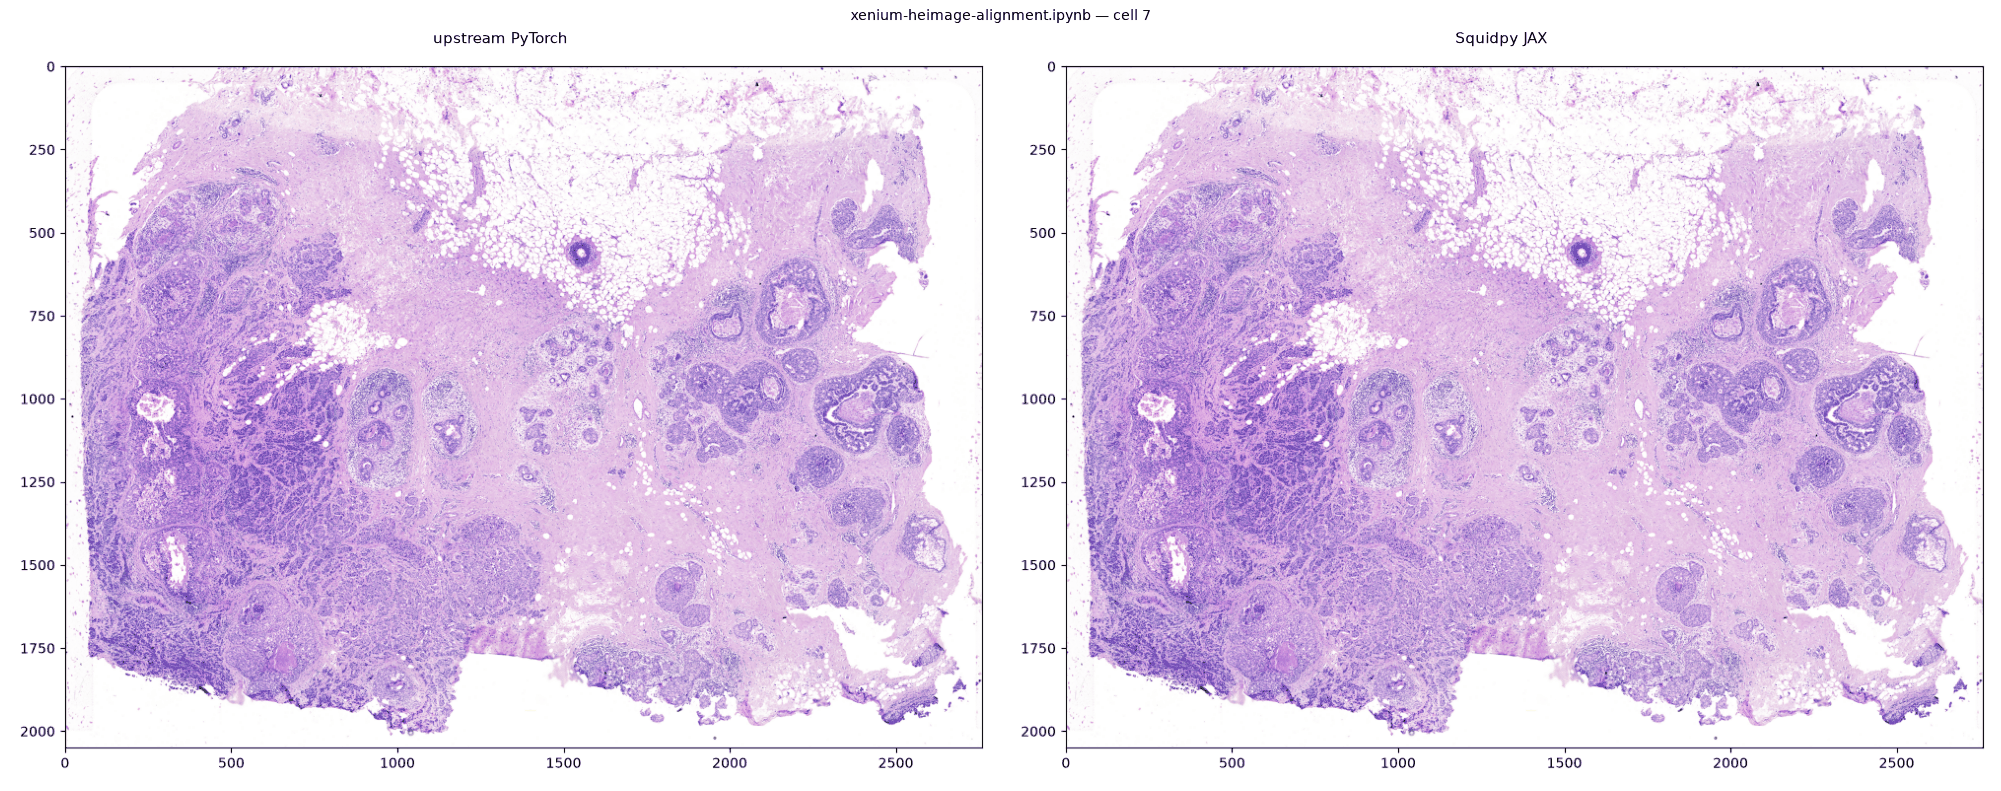

In [2]:
# Target is H&E staining image
image_file = '../xenium_data/Xenium_FFPE_Human_Breast_Cancer_Rep1_he_image.png'
V = plt.imread(image_file)

# plot
fig,ax = plt.subplots()
ax.imshow(V)

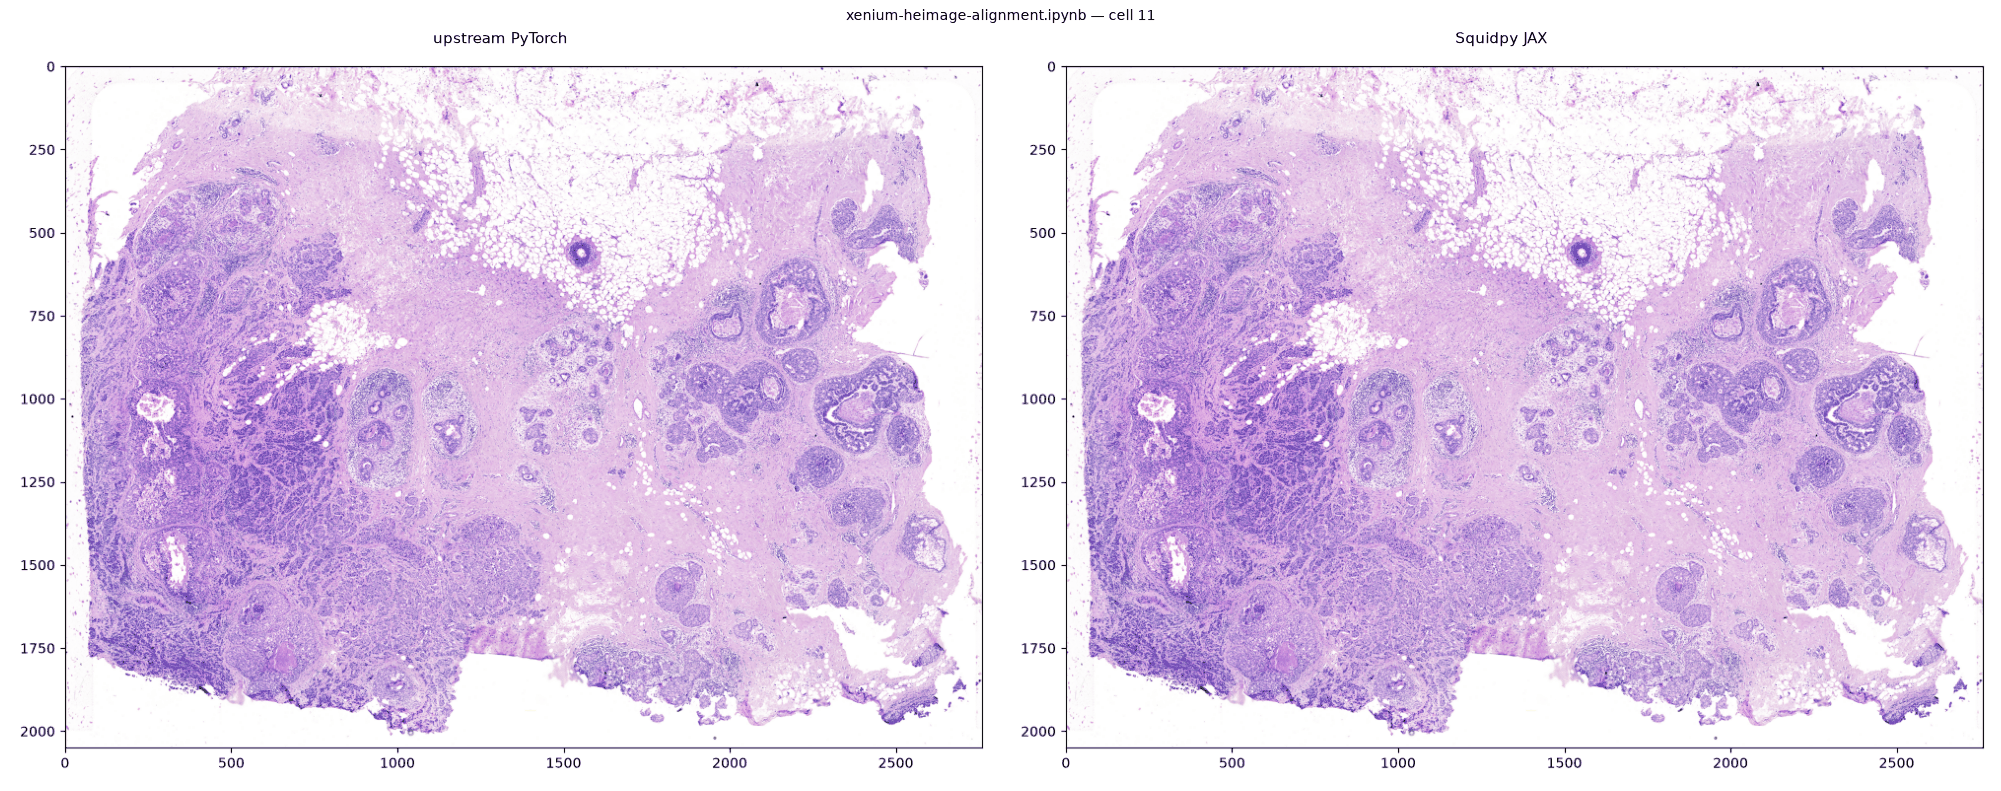

In [3]:
Inorm = STalign.normalize(V)

print(Inorm.min())
print(Inorm.max())

fig,ax = plt.subplots()
ax.imshow(Inorm)

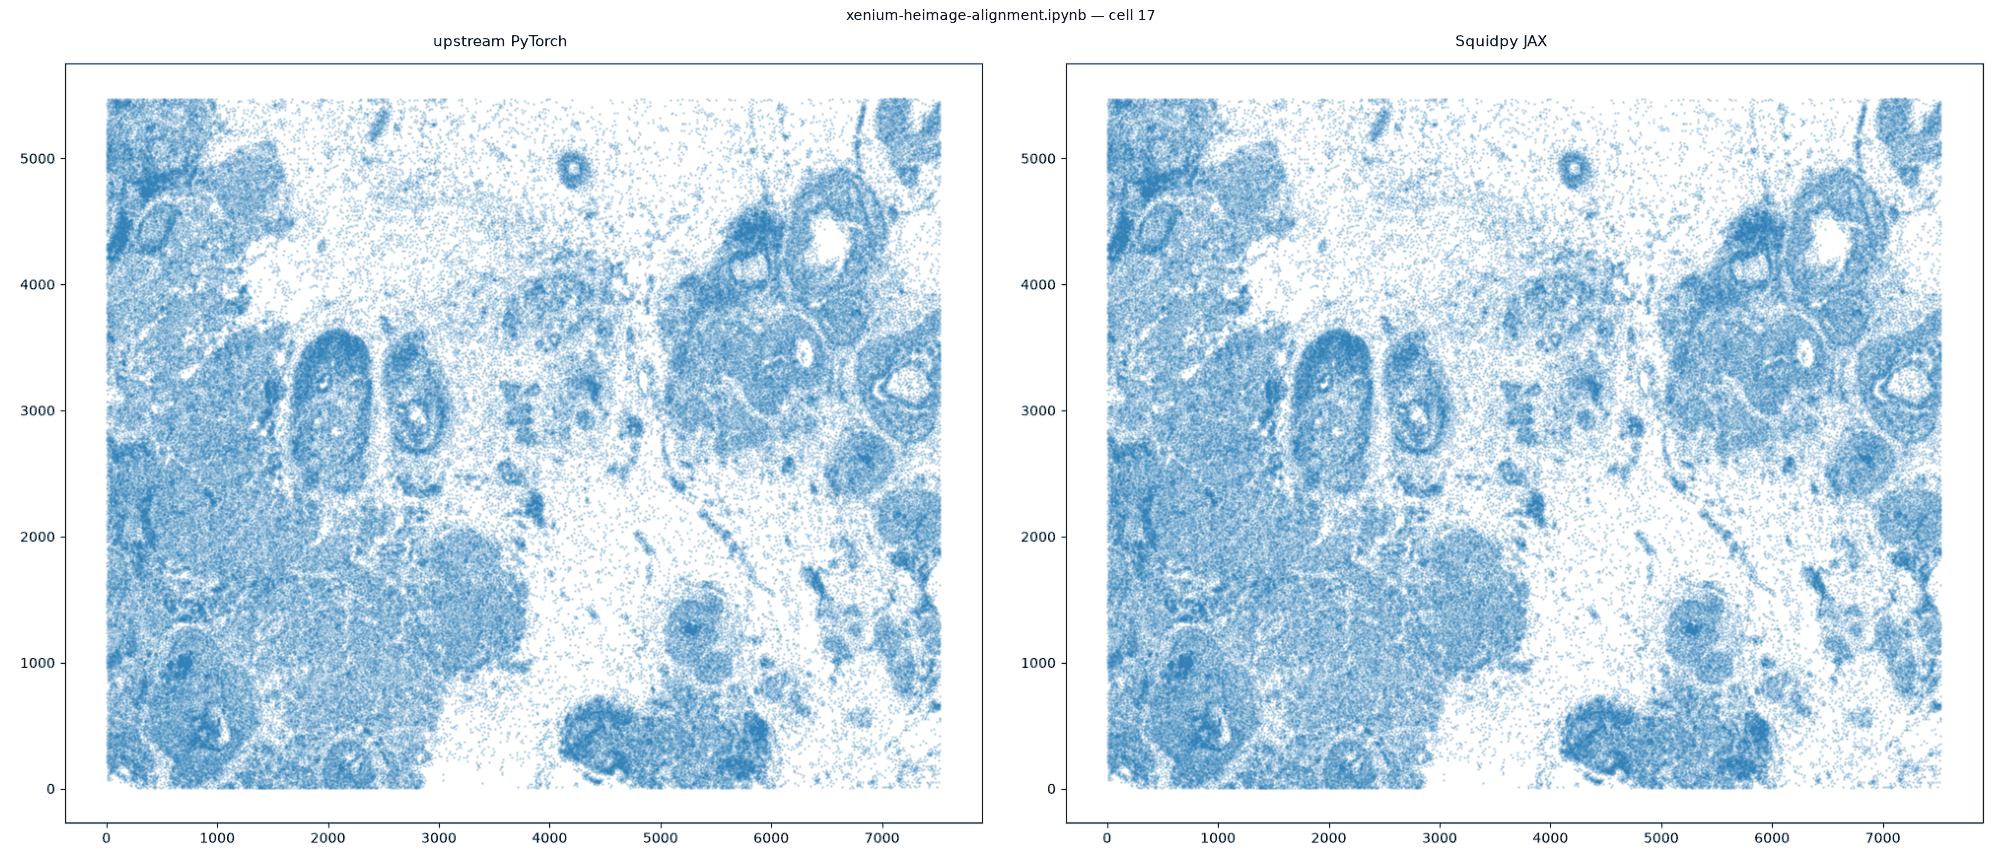

In [4]:
# get cell centroid coordinates
xM = np.array(df['x_centroid'])
yM = np.array(df['y_centroid'])

# plot
fig,ax = plt.subplots()
ax.scatter(xM,yM,s=1,alpha=0.2)

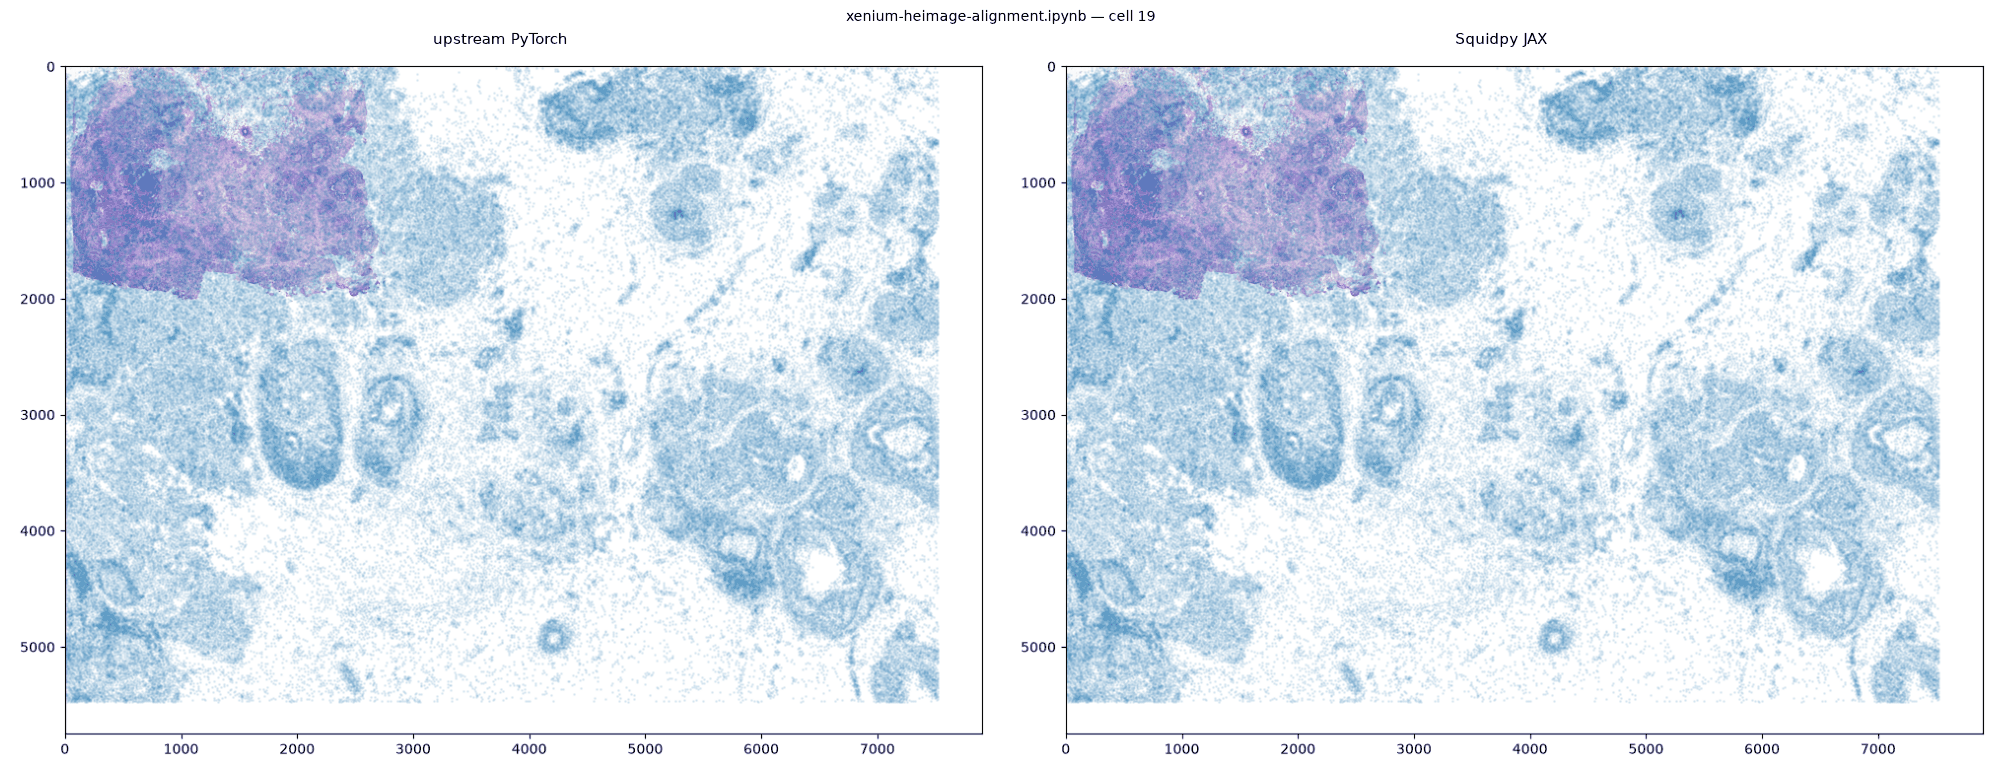

In [5]:
# plot
fig,ax = plt.subplots()
ax.imshow((I).transpose(1,2,0),extent=extentI)
ax.scatter(xM,yM,s=1,alpha=0.1)

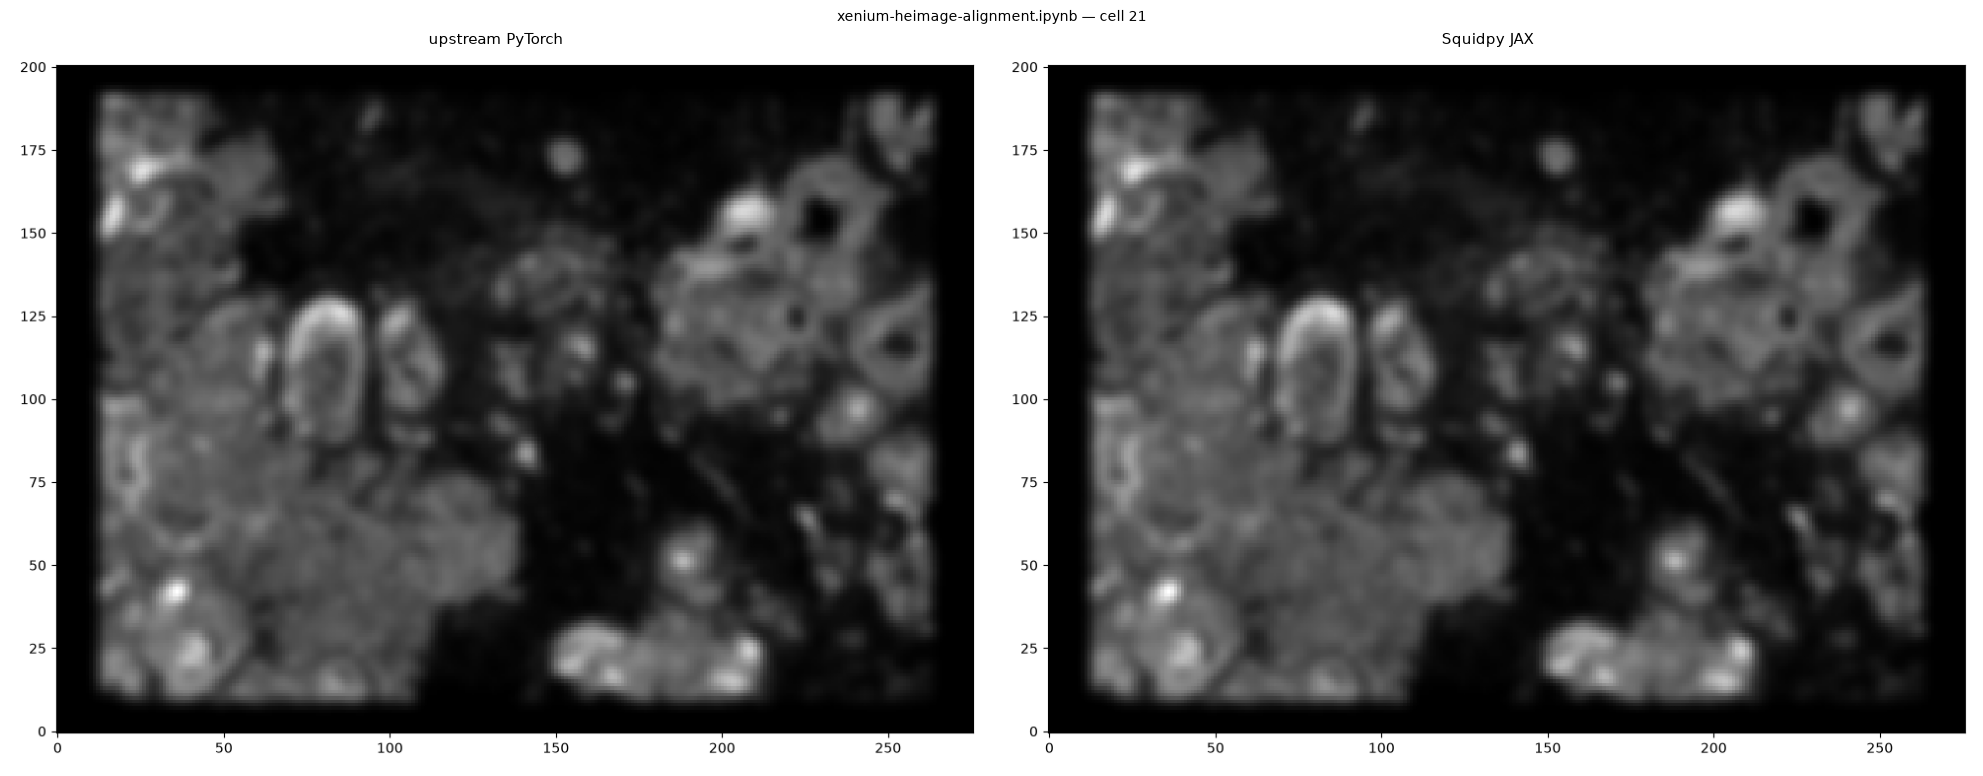

In [6]:
# rasterize at 30um resolution (assuming positions are in um units) and plot
XJ,YJ,M,fig = STalign.rasterize(xM, yM, dx=30)

ax = fig.axes[0]
ax.invert_yaxis()

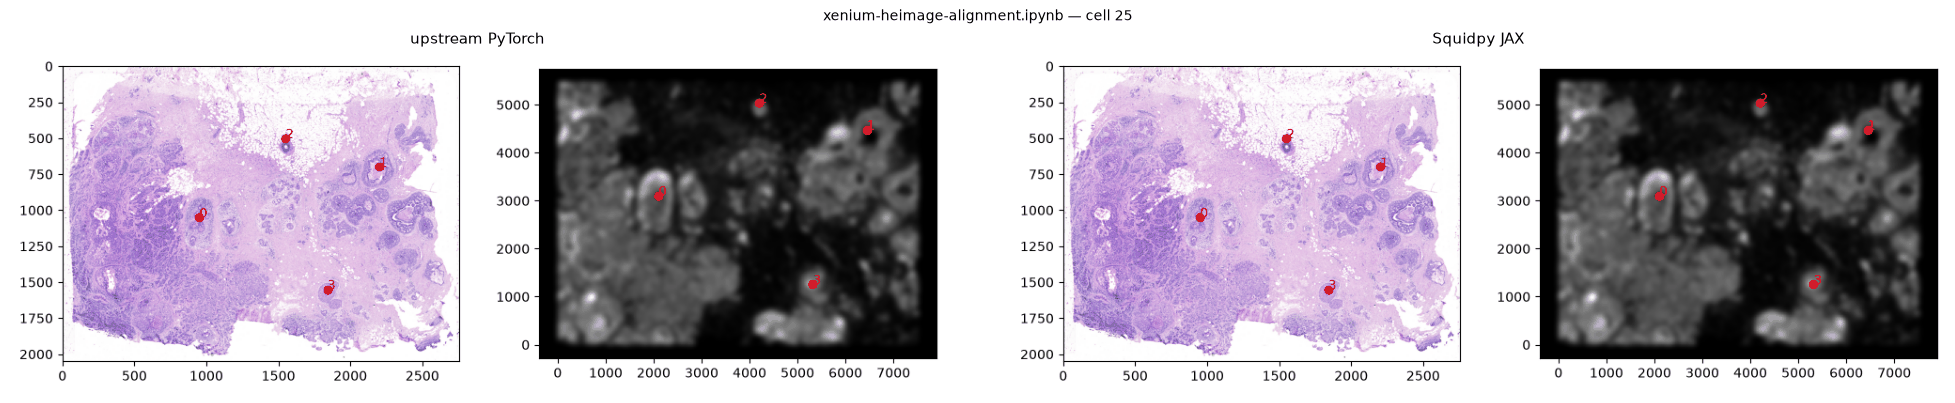

In [7]:
# manually make corresponding points
pointsI = np.array([[1050.,950.], [700., 2200.], [500., 1550.], [1550., 1840.]])
pointsJ = np.array([[3108.,2100.], [4480., 6440.], [5040., 4200.], [1260., 5320.]]) 

# plot
extentJ = STalign.extent_from_x((YJ,XJ))

fig,ax = plt.subplots(1,2)
ax[0].imshow((I.transpose(1,2,0).squeeze()), extent=extentI) 
ax[1].imshow((J.transpose(1,2,0).squeeze()), extent=extentJ) 

ax[0].scatter(pointsI[:,1],pointsI[:,0], c='red')
ax[1].scatter(pointsJ[:,1],pointsJ[:,0], c='red')
for i in range(pointsI.shape[0]):
    ax[0].text(pointsI[i,1],pointsI[i,0],f'{i}', c='red')
    ax[1].text(pointsJ[i,1],pointsJ[i,0],f'{i}', c='red')

# invert only rasterized image
ax[1].invert_yaxis()

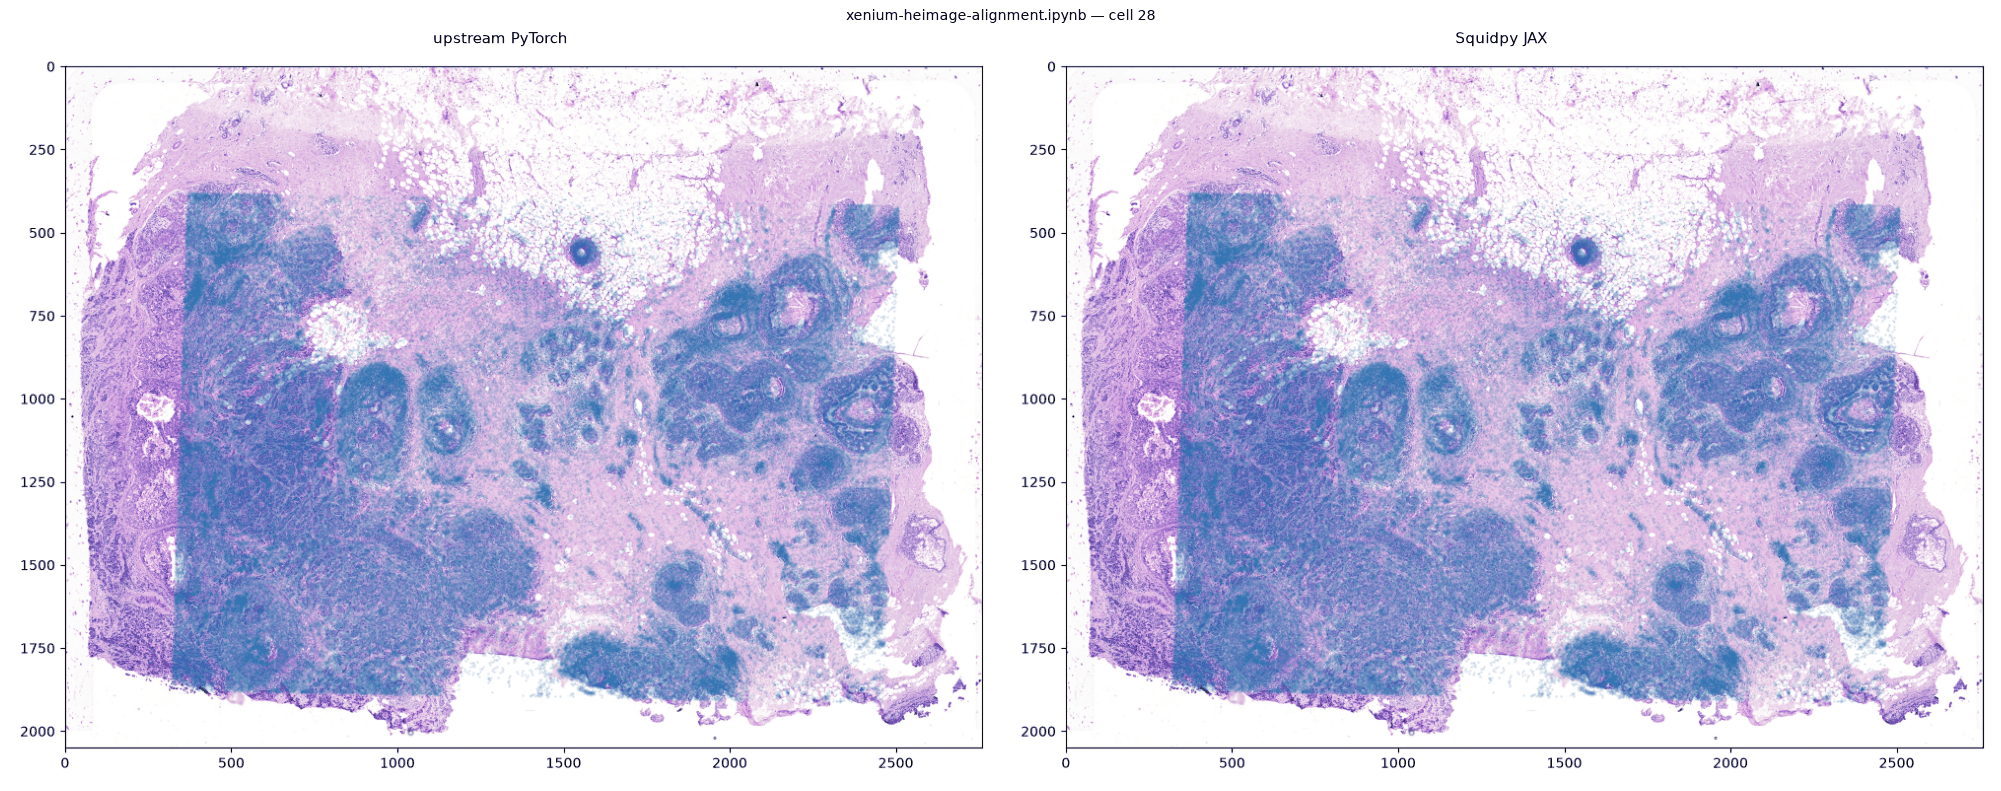

In [8]:
print(L)
print(T)
print(L.shape)
print(T.shape)

# note points are as y,x
affine = np.dot(np.linalg.inv(L), [yM - T[0], xM - T[1]]) 
print(affine.shape)
xMaffine = affine[0,:] 
yMaffine = affine[1,:] 

# plot
fig,ax = plt.subplots()
ax.scatter(yMaffine,xMaffine,s=1,alpha=0.1)
ax.imshow((I).transpose(1,2,0))

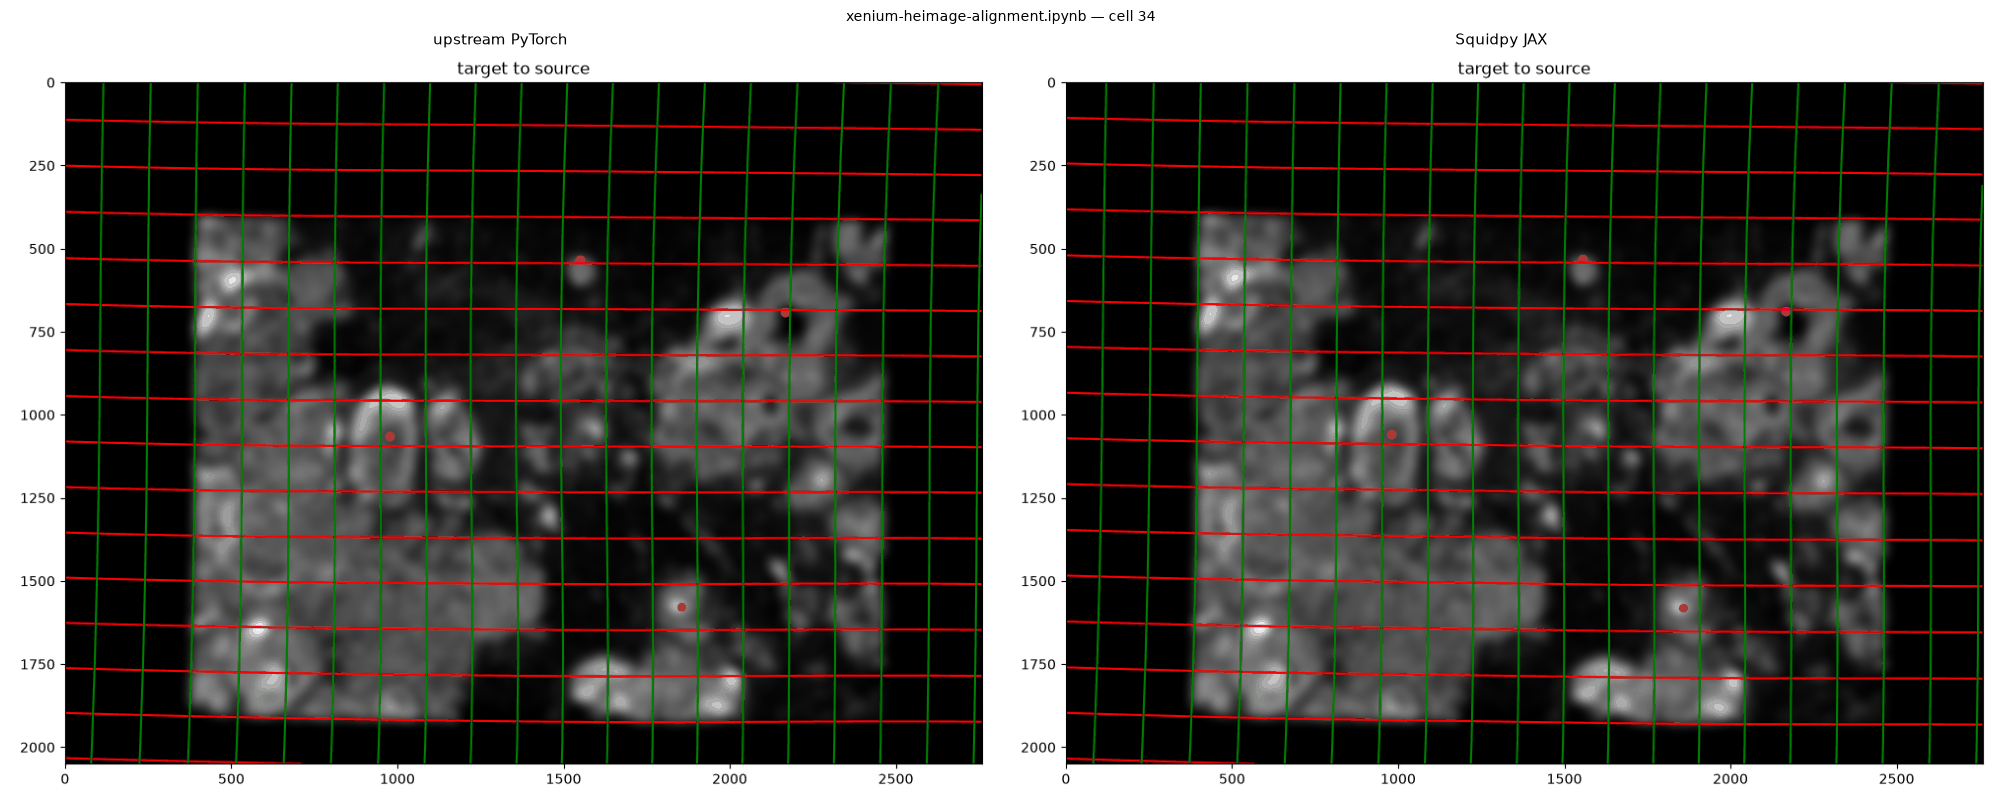

In [9]:
# now transform the points 
phi = STalign.build_transform(xv,v,A,XJ=[YI,XI],direction='f')
phiiJ = STalign.transform_image_target_to_source(xv,v,A,[YJ,XJ],J,[YI,XI])
phiipointsJ = STalign.transform_points_target_to_source(xv,v,A,pointsJ)

#switch tensor from cuda to cpu for plotting with numpy
if phi.is_cuda:
    phi = phi.cpu()
if phiiJ.is_cuda:
    phiiJ = phiiJ.cpu()
if phiipointsJ.is_cuda:
    phiipointsJ = phiipointsJ.cpu()

# plot
fig,ax = plt.subplots()

levels = np.arange(-50000,50000,500)

ax.contour(XI,YI,phi[...,0],colors='r',linestyles='-',levels=levels)
ax.contour(XI,YI,phi[...,1],colors='g',linestyles='-',levels=levels)
ax.set_aspect('equal')
ax.set_title('target to source')

ax.imshow(phiiJ.permute(1,2,0),extent=extentI)
ax.scatter(phiipointsJ[:,1].detach(),phiipointsJ[:,0].detach(),c="m")

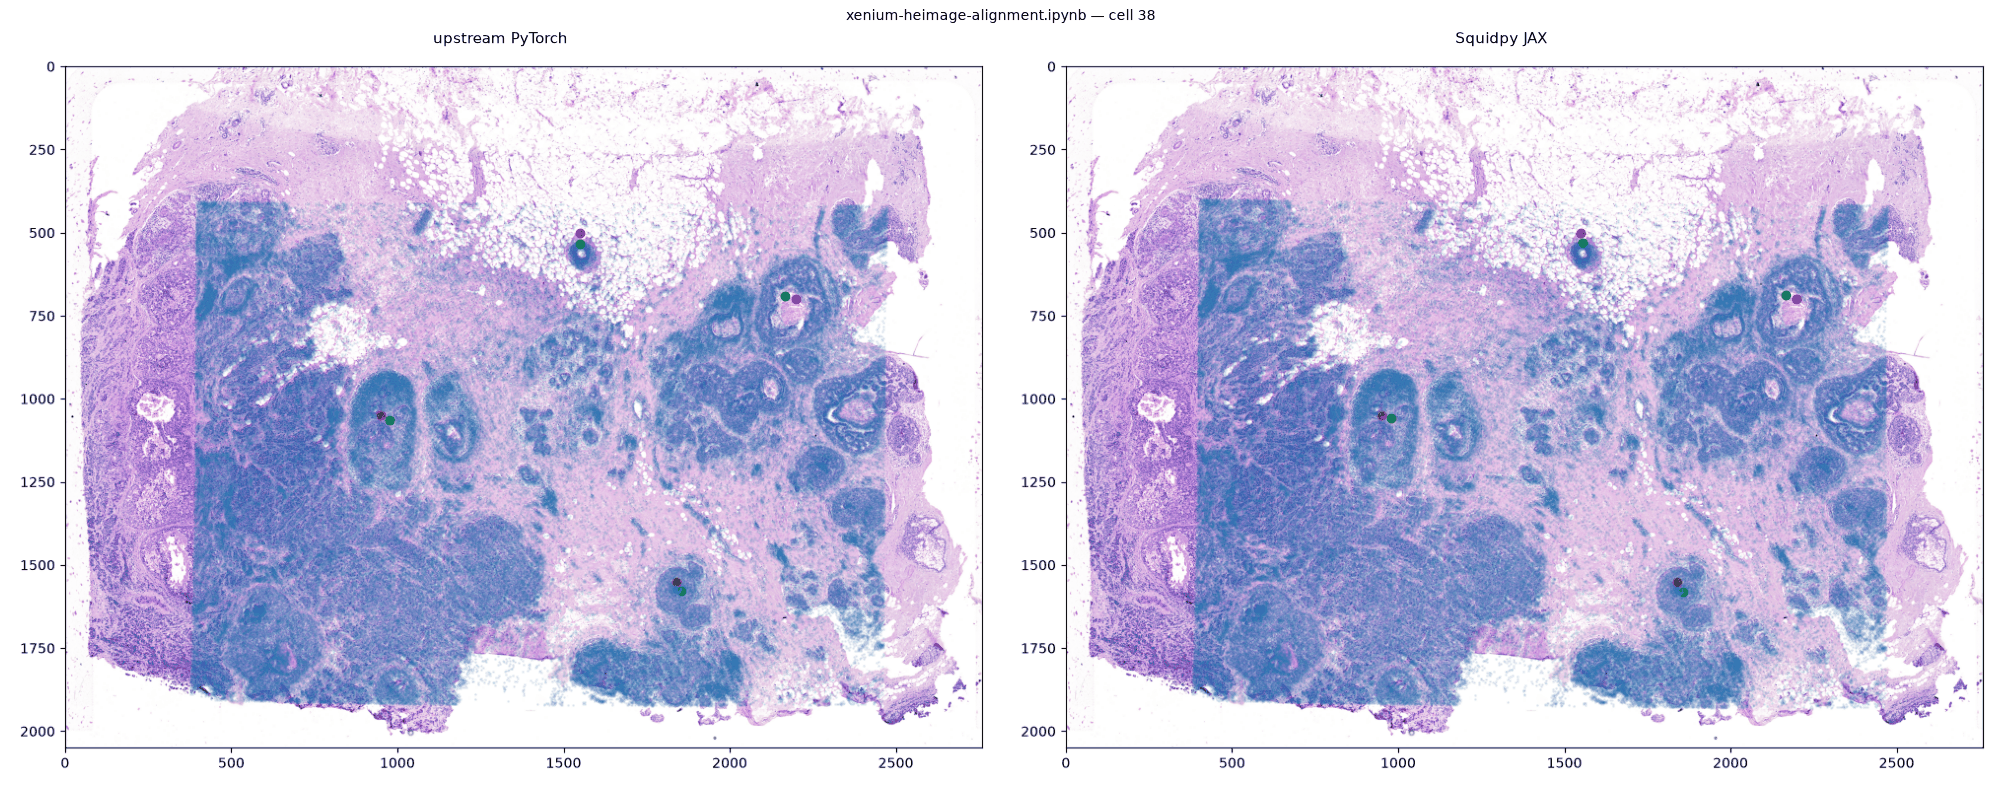

In [10]:
# plot

fig,ax = plt.subplots()
ax.imshow((I).transpose(1,2,0),extent=extentI)
ax.scatter(phiipointsJ[:,1].detach(),phiipointsJ[:,0].detach(),c="g")
ax.scatter(pointsI[:,1],pointsI[:,0], c='r')
ax.scatter(tpointsJ[:,1].detach(),tpointsJ[:,0].detach(),s=1,alpha=0.1)